In [18]:
import mlflow
import mlflow.spark

from pyspark.sql import SparkSession
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler 
from pyspark.ml.pipeline import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit


In [19]:
file_name = "work/dataset/hotel_reservations.csv"

In [20]:
spark = SparkSession.builder.appName("DecisionTreeClassification").getOrCreate()

In [21]:
data = spark.read.csv(file_name, header=True, inferSchema=True)
data.show(5)

+----------+------------+--------------+--------------------+-----------------+-----------------+--------------------------+------------------+---------+------------+-------------+------------+-------------------+--------------+----------------------------+------------------------------------+------------------+----------------------+--------------+
|Booking_ID|no_of_adults|no_of_children|no_of_weekend_nights|no_of_week_nights|type_of_meal_plan|required_car_parking_space|room_type_reserved|lead_time|arrival_year|arrival_month|arrival_date|market_segment_type|repeated_guest|no_of_previous_cancellations|no_of_previous_bookings_not_canceled|avg_price_per_room|no_of_special_requests|booking_status|
+----------+------------+--------------+--------------------+-----------------+-----------------+--------------------------+------------------+---------+------------+-------------+------------+-------------------+--------------+----------------------------+------------------------------------+--

In [22]:
data.printSchema()


root
 |-- Booking_ID: string (nullable = true)
 |-- no_of_adults: integer (nullable = true)
 |-- no_of_children: integer (nullable = true)
 |-- no_of_weekend_nights: integer (nullable = true)
 |-- no_of_week_nights: integer (nullable = true)
 |-- type_of_meal_plan: string (nullable = true)
 |-- required_car_parking_space: integer (nullable = true)
 |-- room_type_reserved: string (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_year: integer (nullable = true)
 |-- arrival_month: integer (nullable = true)
 |-- arrival_date: integer (nullable = true)
 |-- market_segment_type: string (nullable = true)
 |-- repeated_guest: integer (nullable = true)
 |-- no_of_previous_cancellations: integer (nullable = true)
 |-- no_of_previous_bookings_not_canceled: integer (nullable = true)
 |-- avg_price_per_room: double (nullable = true)
 |-- no_of_special_requests: integer (nullable = true)
 |-- booking_status: string (nullable = true)



In [23]:
from pyspark.sql.types import IntegerType, DoubleType, StringType
import pyspark.sql.functions as F
import pandas as pd

In [24]:
string_columns = [field.name for field in data.schema.fields if isinstance(field.dataType, StringType)]
print("String columns:", string_columns)

String columns: ['Booking_ID', 'type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']


In [25]:
double_columns = [field.name for field in data.schema.fields if isinstance(field.dataType, DoubleType)]
print("Double columns:", double_columns)

Double columns: ['avg_price_per_room']


In [26]:
integer_columns = [field.name for field in data.schema.fields if isinstance(field.dataType, IntegerType)]
print("Integer columns:", integer_columns)

Integer columns: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'no_of_special_requests']


In [27]:
(
    data.select([
        F.count(
            F.when(F.col(c).isNull(), 1)
        ).alias(c) for c in data.columns
        ]
    ).show()
)

+----------+------------+--------------+--------------------+-----------------+-----------------+--------------------------+------------------+---------+------------+-------------+------------+-------------------+--------------+----------------------------+------------------------------------+------------------+----------------------+--------------+
|Booking_ID|no_of_adults|no_of_children|no_of_weekend_nights|no_of_week_nights|type_of_meal_plan|required_car_parking_space|room_type_reserved|lead_time|arrival_year|arrival_month|arrival_date|market_segment_type|repeated_guest|no_of_previous_cancellations|no_of_previous_bookings_not_canceled|avg_price_per_room|no_of_special_requests|booking_status|
+----------+------------+--------------+--------------------+-----------------+-----------------+--------------------------+------------------+---------+------------+-------------+------------+-------------------+--------------+----------------------------+------------------------------------+--

In [28]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)


In [29]:
mlflow.set_experiment("hr_decision_tree")
mlflow.pyspark.ml.autolog()
mlflow.set_tracking_uri("http://localhost:5000")

In [30]:
mlflow.end_run()

Input columns for VectorAssembler: ['type_of_meal_plan_encoded', 'room_type_reserved_encoded', 'arrival_month_encoded', 'market_segment_type_encoded', 'no_of_adults_imputed', 'no_of_children_imputed', 'no_of_weekend_nights_imputed', 'no_of_week_nights_imputed', 'required_car_parking_space_imputed', 'lead_time_imputed', 'repeated_guest_imputed', 'no_of_previous_cancellations_imputed', 'no_of_previous_bookings_not_canceled_imputed', 'avg_price_per_room_imputed', 'no_of_special_requests_imputed']


2026/03/04 20:53:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/conda/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


🏃 View run honorable-vole-292 at: http://localhost:5000/#/experiments/881478488680388250/runs/d9078d00ee154d2eb133db9c16c0867a
🧪 View experiment at: http://localhost:5000/#/experiments/881478488680388250
🏃 View run redolent-elk-798 at: http://localhost:5000/#/experiments/881478488680388250/runs/89e500cdb5f4465a8cf83aa9e4fb0d0f
🧪 View experiment at: http://localhost:5000/#/experiments/881478488680388250
🏃 View run overjoyed-yak-251 at: http://localhost:5000/#/experiments/881478488680388250/runs/ccad2ace5bf44fbeb43c9c9633746235
🧪 View experiment at: http://localhost:5000/#/experiments/881478488680388250
🏃 View run thundering-lamb-94 at: http://localhost:5000/#/experiments/881478488680388250/runs/5fa23571056e463786dbf75067da9d59
🧪 View experiment at: http://localhost:5000/#/experiments/881478488680388250
Test Accuracy: 0.8704
Failed to log feature importance plot: 'numpy.ndarray' object has no attribute 'plot'
🏃 View run decision_tree_classification at: http://localhost:5000/#/experiments

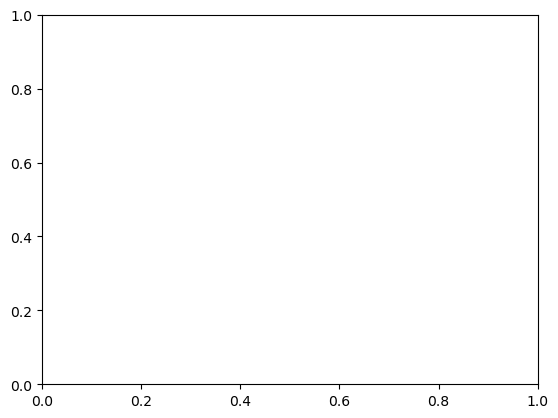

In [31]:
pipeline_stages = []
#mlflow.end_run()
with mlflow.start_run(run_name="decision_tree_classification"):

    categorical_columns = [
        'type_of_meal_plan',
        'room_type_reserved',
        'arrival_month',
        'market_segment_type'
    ]

    numerical_columns = [
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'required_car_parking_space',
    'lead_time',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests'
    ]

    imputer = Imputer(inputCols=numerical_columns, outputCols=[f"{col}_imputed" for col in numerical_columns])
    pipeline_stages.append(imputer)

    for col in categorical_columns:
        indexer = StringIndexer(inputCol=col, outputCol=f"{col}_indexed", handleInvalid="keep")
        #indexer_df = indexer.fit(data).transform(data)
        #indexer_df.select(col, f"{col}_indexed").show(2)

        encoder = OneHotEncoder(inputCol=f"{col}_indexed", outputCol=f"{col}_encoded", dropLast=False)
        #encoder_df = encoder.fit(indexer_df).transform(indexer_df)
        #encoder_df.select(f'{col}', f'{col}_encoded').show(2)
        
        pipeline_stages += [indexer, encoder]


    input_columns = [col + "_encoded" for col in categorical_columns] + [col + "_imputed" for col in numerical_columns]
    print("Input columns for VectorAssembler:", input_columns)

    pipeline_stages += [StringIndexer(inputCol="booking_status", outputCol="booking_status_indexed", handleInvalid="keep")]

    assembler = VectorAssembler(inputCols=input_columns, outputCol="features_unscaled", handleInvalid="keep")
    scaler = StandardScaler(inputCol="features_unscaled", outputCol="features") 
    dt = DecisionTreeClassifier(labelCol="booking_status_indexed", featuresCol="features")
    pipeline_stages += [assembler, scaler, dt]
    pipeline = Pipeline(stages=pipeline_stages)

    grid = (
        ParamGridBuilder()
            .addGrid(dt.maxDepth, [5, 10])
            .addGrid(dt.maxBins, [32, 64])
            .build()
    )
    tvs = (
            TrainValidationSplit(estimator = pipeline,estimatorParamMaps=grid,evaluator = MulticlassClassificationEvaluator(labelCol="booking_status_indexed", metricName="accuracy"),trainRatio=0.8)
           )

    model = tvs.fit(train_data)
    mlflow.spark.log_model(model.bestModel, "decision_tree_model")
    
    # Evaluate the model on the test set
    predictions = model.transform(test_data)
    evaluator = MulticlassClassificationEvaluator(labelCol="booking_status_indexed", metricName="accuracy")
    accuracy = evaluator.evaluate(predictions)
    mlflow.log_metric("test_accuracy", accuracy)
    print(f"Test Accuracy: {accuracy:.4f}")

    # Log feature importance plot (if available)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots()
        model.bestModel.stages[-1].featureImportances.toArray().plot(kind="barh", ax=ax)
        plt.title("Feature Importance")
        mlflow.log_figure(fig, "feature_importance.png")
    except Exception as e:
        print(f"Failed to log feature importance plot: {e}")
